# **Business Case - DELHIVERY**

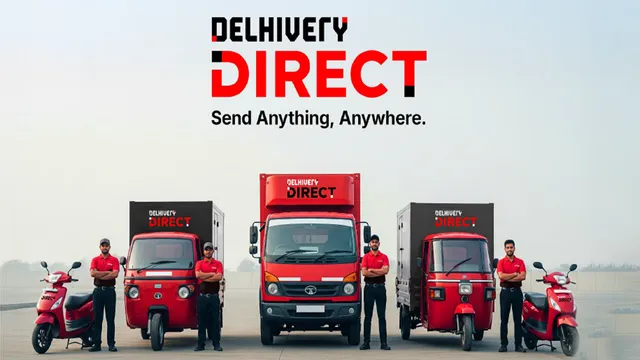

## **Introduction**

Delhivery is one of India’s largest integrated logistics and supply chain companies. It operates across multiple transportation modes such as Full Truck Load (FTL) and Carting, managing shipments between various source and destination centers across the country.

In logistics operations, efficiency in delivery time, route optimization, and forecasting accuracy plays a critical role in reducing costs and improving customer satisfaction. The dataset provided contains detailed trip-level and segment-level delivery information, including actual time taken, estimated time using OSRM (Open Source Routing Machine), distances, and timestamps.

However, the dataset is raw and structured at a segment level, where a single trip may be divided into multiple rows. Before this data can be used for forecasting models or business analysis, it needs to be cleaned, structured, and transformed.

## **Problem Statement**

The primary problem in this case study is to transform raw, segment-level logistics data into a clean, structured, and trip-level dataset that can be used for meaningful analysis and forecasting.

Currently, the data:

- Contains multiple rows for a single trip

- Includes cumulative and segment-level time and distance values

- Has timestamp fields that require conversion

- May contain missing values and outliers

- Lacks engineered features necessary for predictive modeling

The challenge is to process this data in a way that ensures accuracy, consistency, and usability for downstream analytics and machine learning tasks.

## **Objective of the Case Study**

The main objectives of this business case study are:

1. To clean and preprocess the dataset by handling missing values, correcting data types, and converting time columns into proper datetime formats.

2. To merge and aggregate segment-level rows into meaningful segment-level and trip-level summaries using appropriate grouping and aggregation techniques.

3. To perform feature engineering by extracting useful information such as trip duration, month, year, city, state, and time-based features.

4. To compare actual delivery time with OSRM estimated time to evaluate route efficiency and estimation accuracy.

5. To detect and handle outliers in numerical features using statistical techniques like the IQR method.

6. To prepare the dataset for modeling by applying one-hot encoding to categorical variables and scaling numerical variables.

7. To derive actionable business insights that can help Delhivery improve operational efficiency, reduce delays, and optimize logistics planning.

## **Business Relevance**

This case study helps understand how logistics data can be transformed into meaningful insights. By analyzing actual versus estimated time, identifying busy corridors, and examining delivery patterns across states and routes, Delhivery can:

- Improve time forecasting accuracy

- Optimize route planning

- Reduce operational inefficiencies

- Enhance customer satisfaction

The structured dataset produced after feature engineering can also be used by the data science team to build reliable forecasting models for delivery time prediction.

## **Importing Libraries and Dataset**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [225]:
# dataset link:-
# https://docs.google.com/spreadsheets/d/e/2PACX-1vRL2Humv8jYZRFckqOjGauGw-pvFOGGqQyJWVycx729zJj-tDPh2fKsbAPjZG_TJE7eHTCzDGjxTS5R/pub?gid=1814535743&single=true&output=csv

# colab notebook link:-
# https://drive.google.com/file/d/111lH3FMCcqrlX_dVolKWCTrrFx9xuxHS/view?usp=sharing

In [ ]:
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRL2Humv8jYZRFckqOjGauGw-pvFOGGqQyJWVycx729zJj-tDPh2fKsbAPjZG_TJE7eHTCzDGjxTS5R/pub?gid=1814535743&single=true&output=csv"
delhivery_data = pd.read_csv(url)
print(delhivery_data)

            data   trip_creation_time  \
0       training   2018-09-20 2:35:36   
1       training   2018-09-20 2:35:36   
2       training   2018-09-20 2:35:36   
3       training   2018-09-20 2:35:36   
4       training   2018-09-20 2:35:36   
...          ...                  ...   
144862  training  2018-09-20 16:24:28   
144863  training  2018-09-20 16:24:28   
144864  training  2018-09-20 16:24:28   
144865  training  2018-09-20 16:24:28   
144866  training  2018-09-20 16:24:28   

                                      route_schedule_uuid route_type  \
0       thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   
1       thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   
2       thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   
3       thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   
4       thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   
...                                                   ...        ...   
144

In [ ]:
# Creating copy of dataset to preserve the originality
df = delhivery_data.copy()
df

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 4:27:55,10.435660,14,11,11.9653,1.272727,14,11,11.9653,1.272727
1,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 4:17:55,18.936842,24,20,21.7243,1.200000,10,9,9.7590,1.111111
2,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 4:01:20,27.637279,40,28,32.5395,1.428571,16,7,10.8152,2.285714
3,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 3:39:57,36.118028,62,40,45.5620,1.550000,21,12,13.0224,1.750000
4,training,2018-09-20 2:35:36,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 3:21:32,...,2018-09-20 3:33:55,39.386040,68,44,54.2181,1.545455,6,5,3.9153,1.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144862,training,2018-09-20 16:24:28,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28,...,2018-09-20 21:57:20,45.258278,94,60,67.9280,1.566667,12,12,8.1858,1.000000
144863,training,2018-09-20 16:24:28,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28,...,2018-09-20 21:31:18,54.092531,120,76,85.6829,1.578947,26,21,17.3725,1.238095
144864,training,2018-09-20 16:24:28,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28,...,2018-09-20 21:11:18,66.163591,140,88,97.0933,1.590909,20,34,20.7053,0.588235
144865,training,2018-09-20 16:24:28,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28,...,2018-09-20 20:53:19,73.680667,158,98,111.2709,1.612245,17,27,18.8885,0.629630


## **Dataset - Column Profiling:**

1. **data** - tells whether the data is testing or training data

2. **trip_creation_time** – Timestamp of trip creation

3. **route_schedule_uuid** – Unique ID for a particular route schedule

4. **route_type** – Transportation type

  a. **Full Truck Load:** FTL shipments get to the destination sooner, as the truck is making no other pickups or drop-offs along the way
  
  b. **Carting:** Handling system consisting of small vehicles (carts)

5. **trip_uuid** - Unique ID given to a particular trip (A trip may include different source and destination centers)

6. **source_center** - Source ID of trip origin

7. **source_name** - Source Name of trip origin

8. **destination_center** – Destination ID

9. **destination_name** – Destination Name

10. **od_start_time** – Trip start time

11. **od_end_time** – Trip end time

12. **start_scan_to_end_scan** – Time taken to deliver from source to destination

13. **is_cutoff** – Unknown field

14. **cutoff_factor** – Unknown field

15. **cutoff_timestamp** – Unknown field

16. **actual_distance_to_destination** – Distance in kms between source and destination warehouse

17. **actual_time** – Actual time taken to complete the delivery **(Cumulative)**

18. **osrm_time** – An open-source routing engine time calculator which computes the shortest path between points in a given map (Includes usual traffic, distance through major and minor roads) and gives the time **(Cumulative)**

19. **osrm_distance** – An open-source routing engine which computes the shortest path between points in a given map (Includes usual traffic, distance through major and minor roads) **(Cumulative)**

20. **factor** – Unknown field

21. **segment_actual_time** – This is a segment time. Time taken by the subset of the package delivery

22. **segment_osrm_time** – This is the OSRM segment time. Time taken by the subset of the package delivery

23. **segment_osrm_distance** – This is the OSRM distance. Distance covered by subset of the package delivery

24. **segment_factor** – Unknown field

## **Exploration and Data Cleaning**

In [ ]:
print("The number of rows:", df.shape[0])
print("The number of columns:", df.shape[1])
print("===="*10)
df.info()

The number of rows: 144867
The number of columns: 24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan   

The dataset contains 144,867 rows and 24 columns. However, there are only 14,817 unique trip_uuid values. This confirms that the dataset is recorded at a segment level rather than a trip level, meaning that each trip is divided into multiple rows representing different segments of the journey.

On average, each trip consists of approximately 9–10 segment records. This indicates that aggregation will be required later to construct trip-level summaries for forecasting and business analysis.

In [ ]:
print("Unique Trips:", df['trip_uuid'].nunique())
print("Total Rows:", len(df))

Unique Trips: 14817
Total Rows: 144867


The dataset contains 14,817 unique trips across 144,867 rows.

This confirms that the dataset is recorded at a segment level, meaning multiple rows correspond to a single trip.

**On average:**

144,867 / 14,817 ≈ 9.77 segments per trip

This indicates that aggregation will be required later to construct trip-level summaries.

In [ ]:
# Coverting necessary columns into their data types
datetime_cols = ['trip_creation_time','od_start_time','od_end_time','cutoff_timestamp']

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col])

All time-related columns were initially stored as object data type. These were converted into pandas datetime format to enable time-based feature extraction and duration calculations. Converting these columns ensures accurate time computations and supports further analysis such as trip duration, monthly trends, and time-based aggregations.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
missing_percent = (df.isna().sum()/len(df))*100
missing_percent

,0
data,0.000000
trip_creation_time,0.000000
route_schedule_uuid,0.000000
route_type,0.000000
trip_uuid,0.000000
source_center,0.000000
source_name,0.202254
destination_center,0.000000
destination_name,0.180165
od_start_time,0.000000


Missing values exist only in:

- source_name: 293 rows (0.20%)

- destination_name: 261 rows (0.18%)

Since missing values account for less than 0.5% of the dataset, they can be safely removed.

In [ ]:
df = df.dropna(subset=['source_name','destination_name'])

After removing 551 rows (0.38% of total data), the dataset now contains:

In [ ]:
print("Updated Rows:", len(df))
print("Updated Unique Trips:", df['trip_uuid'].nunique())

Updated Rows: 144316
Updated Unique Trips: 14787


In [ ]:
(df['od_end_time'] < df['od_start_time']).sum()
(df['actual_time'] <= 0).sum()
df.duplicated().sum()
(df['actual_distance_to_destination'] < 0).sum()

np.int64(0)

- No cases where od_end_time is earlier than od_start_time

- No negative or zero actual_time values

- No duplicate rows

- No negative distance values

This confirms structural consistency of the dataset.

In [ ]:
df['data'].value_counts(normalize=True)*100

,proportion
data,
training,72.502009
test,27.497991


The data column tells us whether a particular record belongs to Training or Test dataset

This means the original dataset was likely prepared for a machine learning task, where:

- 72.5% of records are used to train a model

- 27.5% are reserved to test model performance

In [ ]:
df['route_type'].value_counts(normalize=True)*100

,proportion
route_type,
FTL,68.690928
Carting,31.309072


- FTL (Full Truck Load): 68.69%

- Carting: 31.31%

Nearly two-thirds of shipments are handled via FTL. Since FTL shipments involve dedicated trucks, delivery performance may differ significantly from Carting shipments.

This distinction will be important during further analysis.

In [ ]:
df.describe()

,trip_creation_time,od_start_time,od_end_time,start_scan_to_end_scan,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144316,144316,144316,144316.000000,144316.000000,144316,144316.000000,144316.000000,144316.000000,144316.000000,144316.000000,144316.000000,144316.000000,144316.000000,144316.000000
mean,2018-09-22 13:05:09.445321216,2018-09-22 17:32:42.431788800,2018-09-23 09:36:54.055503104,963.697698,233.561345,2018-09-23 02:03:47.744546816,234.708498,417.996237,214.437055,285.549785,2.120178,36.175379,18.495697,22.818993,2.218707
min,2018-09-12 00:00:17,2018-09-12 00:00:17,2018-09-12 00:50:11,20.000000,9.000000,2018-09-12 00:02:10,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.000000,-23.444444
25%,2018-09-17 02:46:11,2018-09-17 07:37:35.249999872,2018-09-18 01:29:57,161.000000,22.000000,2018-09-17 18:30:36.750000128,23.352027,51.000000,27.000000,29.896250,1.604545,20.000000,11.000000,12.053975,1.347826
50%,2018-09-22 03:36:19,2018-09-22 07:35:23,2018-09-23 02:49:01,451.000000,66.000000,2018-09-22 19:27:22,66.135322,132.000000,64.000000,78.624400,1.857143,28.000000,17.000000,23.508300,1.684211
75%,2018-09-27 17:53:19,2018-09-27 22:01:31,2018-09-28 12:13:42,1645.000000,286.000000,2018-09-28 04:56:21.500000,286.919294,516.000000,259.000000,346.305400,2.212280,40.000000,22.000000,27.813325,2.250000
max,2018-10-03 23:59:43,2018-10-06 04:27:23,2018-10-08 03:00:24,7898.000000,1927.000000,2018-10-06 23:44:12,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.403700,574.250000
std,NaN,NaN,NaN,1038.082976,345.245823,NaN,345.480571,598.940065,308.448543,421.717826,1.717065,53.524298,14.774008,17.866367,4.854804


**Key Observations**

- Average actual delivery time: 417.99 minutes (~6.97 hours)

- Average OSRM estimated time: 214.44 minutes (~3.57 hours)

Actual time is nearly 95% higher than estimated time on average, suggesting systematic underestimation by OSRM.

- Average actual distance: 234.71 km

- Maximum actual_time: 4,532 minutes (~75.5 hours)

The wide range indicates presence of extreme outliers.

**Preliminary Outlier Observations**

From descriptive statistics:

- segment_actual_time minimum: -244 minutes (logically impossible)

- segment_factor minimum: -23.44

- segment_factor maximum: 574.25

- segment_actual_time maximum: 3,051 minutes

Negative time values are not possible in real-world logistics, indicating data anomalies. These extreme values will be handled later using IQR-based outlier detection.

In [ ]:
(df['actual_time'] < df['osrm_time']).sum()

np.int64(2547)

In [ ]:
(df['actual_time'] > df['osrm_time']).mean()

np.float64(0.9785332187699216)

**Observation**

- In 2,547 cases (1.76%), actual_time is less than osrm_time.

- In 97.85% of cases, actual_time exceeds osrm_time.

This suggests OSRM systematically underestimates real delivery time.

**Possible reasons:**

- Traffic congestion

- Loading/unloading delays

- Operational inefficiencies

- Route diversions

In [ ]:
print(df['trip_creation_time'].min())
print(df['trip_creation_time'].max())

2018-09-12 00:00:17
2018-10-03 23:59:43


The dataset covers deliveries from **12 September 2018 to 3 October 2018**. This spans approximately 21 days of operations. While sufficient for operational analysis, the dataset does not capture long-term seasonal patterns.

In [ ]:
df[['actual_time','actual_distance_to_destination']].corr()

,actual_time,actual_distance_to_destination
actual_time,1.000000,0.978683
actual_distance_to_destination,0.978683,1.000000


**Observation**

- There is an extremely strong positive correlation (97.87%) between delivery time and delivery distance.

**Business Insight**

This indicates that delivery time increases almost proportionally with distance. Distance is a dominant factor influencing delivery duration.

A correlation this high suggests:

- Distance is a strong predictor for delivery time.

- Forecasting models will heavily rely on distance-based features.

- Operational delays may scale with route length.

In [ ]:
# Average Difference Between Actual and OSRM Time
df['time_difference'] = df['actual_time'] - df['osrm_time']
df['time_difference'].mean()

np.float64(203.55918262701294)

On average, actual delivery time exceeds OSRM estimated time by approximately 203 minutes (~3.4 hours).

**Business Insight**

This is a significant deviation.

It suggests:

- OSRM routing engine underestimates delivery time.

- Operational factors such as traffic congestion, loading delays, route diversions, and hub processing time are not fully captured in the route estimation model.

- There is a consistent positive bias in actual delivery time.

In [ ]:
df[['actual_time','osrm_time','actual_distance_to_destination']].skew()

,0
actual_time,2.062382
osrm_time,2.039250
actual_distance_to_destination,1.985217


- The distributions are highly positively skewed (right-skewed).

The high skewness suggests that while most deliveries operate within expected time ranges, a small number of routes experience substantial delays.These extreme delays may be caused by:

- Long-haul interstate routes

- Traffic congestion

- Operational bottlenecks

- Multi-hub routing

In [ ]:
# Dropping unknown fields
df.drop(columns=['is_cutoff','cutoff_factor','cutoff_timestamp','factor','segment_factor'], inplace=True)
df.columns

Index(['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type',
       'trip_uuid', 'source_center', 'source_name', 'destination_center',
       'destination_name', 'od_start_time', 'od_end_time',
       'start_scan_to_end_scan', 'actual_distance_to_destination',
       'actual_time', 'osrm_time', 'osrm_distance', 'segment_actual_time',
       'segment_osrm_time', 'segment_osrm_distance', 'time_difference'],
      dtype='object')

Certain columns such as is_cutoff, cutoff_factor, and cutoff_timestamp were removed from the dataset as their business definitions were unclear and they were not required for the objectives of this case study.

These columns do not directly contribute to delivery time forecasting or segment aggregation. Removing them simplifies the dataset and reduces noise without affecting core delivery metrics.

## **Merge Rows**

Here, in the given dataset, delivery details of one package is divided into several rows i.e. Each trip_uuid has multiple rows and Each row represents a segment of the journey. We need to merge rows properly to create segment-level summaries.

In [ ]:
# Create a unique identifier using
df['segment_key'] = df['trip_uuid'] + '_' + df['source_center'] + '_' + df['destination_center']
df[['trip_uuid','source_center','destination_center','segment_key']].head()

,trip_uuid,source_center,destination_center,segment_key
0,trip-153741093647649320,IND388121AAA,IND388620AAB,trip-153741093647649320_IND388121AAA_IND388620AAB
1,trip-153741093647649320,IND388121AAA,IND388620AAB,trip-153741093647649320_IND388121AAA_IND388620AAB
2,trip-153741093647649320,IND388121AAA,IND388620AAB,trip-153741093647649320_IND388121AAA_IND388620AAB
3,trip-153741093647649320,IND388121AAA,IND388620AAB,trip-153741093647649320_IND388121AAA_IND388620AAB
4,trip-153741093647649320,IND388121AAA,IND388620AAB,trip-153741093647649320_IND388121AAA_IND388620AAB


A new column segment_key was created using the combination of trip_uuid, source_center, and destination_center.

This uniquely identifies each delivery segment within a trip and allows grouping of rows belonging to the same segment.

In [ ]:
df = df.sort_values(['segment_key','od_end_time'])

The dataset was sorted by segment_key and od_end_time to maintain chronological order of segment events. This is necessary before applying cumulative aggregation functions.

In [ ]:
# merging rows
df['segment_actual_time_sum'] = df.groupby('segment_key')['segment_actual_time'].cumsum()
df['segment_osrm_time_sum'] = df.groupby('segment_key')['segment_osrm_time'].cumsum()
df['segment_osrm_distance_sum'] = df.groupby('segment_key')['segment_osrm_distance'].cumsum()
# verifying the merged rows
df[['segment_key','segment_actual_time','segment_actual_time_sum','segment_osrm_time',
    'segment_osrm_time_sum','segment_osrm_distance','segment_osrm_distance_sum']].head(10)

,segment_key,segment_actual_time,segment_actual_time_sum,segment_osrm_time,segment_osrm_time_sum,segment_osrm_distance,segment_osrm_distance_sum
125002,trip-153671041653548748_IND209304AAA_IND000000ACB,50,50,33,33,38.0620,38.0620
125003,trip-153671041653548748_IND209304AAA_IND000000ACB,9,59,8,41,10.9921,49.0541
125004,trip-153671041653548748_IND209304AAA_IND000000ACB,34,93,22,63,30.6308,79.6849
125005,trip-153671041653548748_IND209304AAA_IND000000ACB,25,118,17,80,25.0959,104.7808
125006,trip-153671041653548748_IND209304AAA_IND000000ACB,20,138,14,94,21.0389,125.8197
125007,trip-153671041653548748_IND209304AAA_IND000000ACB,38,176,81,175,79.9645,205.7842
125008,trip-153671041653548748_IND209304AAA_IND000000ACB,41,217,78,253,101.3602,307.1444
125009,trip-153671041653548748_IND209304AAA_IND000000ACB,50,267,28,281,40.8743,348.0187
125010,trip-153671041653548748_IND209304AAA_IND000000ACB,56,323,19,300,27.0127,375.0314
125011,trip-153671041653548748_IND209304AAA_IND000000ACB,28,351,16,316,23.6588,398.6902


Cumulative sums were computed for segment_actual_time, segment_osrm_time, and segment_osrm_distance, lastly grouped by segment_key.

These new columns represent the running total time and distance within each segment, enabling proper aggregation of multiple rows belonging to the same delivery segment.

In [ ]:
creating_dict_segment = {

    # categorical / constant columns
    'data': 'first',
    'trip_creation_time': 'first',
    'route_schedule_uuid': 'first',
    'route_type': 'first',
    'trip_uuid': 'first',
    'source_center': 'first',
    'source_name': 'first',
    'destination_center': 'first',
    'destination_name': 'first',
    'od_start_time': 'first',

    # final values
    'od_end_time': 'last',
    'actual_distance_to_destination': 'last',
    'actual_time': 'last',
    'osrm_time': 'last',
    'osrm_distance': 'last',
    'time_difference': 'last',

    # cumulative segment totals
    'segment_actual_time_sum': 'last',
    'segment_osrm_time_sum': 'last',
    'segment_osrm_distance_sum': 'last'
}

In [ ]:
segment = df.groupby('segment_key').agg(creating_dict_segment).reset_index()

In [ ]:
segment = segment.sort_values(['segment_key','od_end_time'])

In [ ]:
print("Original rows:", df.shape)
print("Segment rows:", segment.shape)

segment.head()

Original rows: (144316, 24)
Segment rows: (26222, 20)


,segment_key,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,time_difference,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
0,trip-153671041653548748_IND209304AAA_IND000000ACB,training,2018-09-12 00:00:17,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:47,2018-09-13 13:40:23,383.759164,732,329,446.5496,403,728,534,670.6205
1,trip-153671041653548748_IND462022AAA_IND209304AAA,training,2018-09-12 00:00:17,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,trip-153671041653548748,IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),2018-09-12 00:00:17,2018-09-12 16:39:47,440.973689,830,388,544.8027,442,820,474,649.8528
2,trip-153671042288605164_IND561203AAB_IND562101AAA,training,2018-09-12 00:00:23,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,trip-153671042288605164,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),IND562101AAA,Chikblapur_ShntiSgr_D (Karnataka),2018-09-12 02:03:10,2018-09-12 03:02:00,24.644021,47,26,28.1994,21,46,26,28.1995
3,trip-153671042288605164_IND572101AAA_IND561203AAB,training,2018-09-12 00:00:23,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,trip-153671042288605164,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 00:00:23,2018-09-12 02:03:10,48.542890,96,42,56.9116,54,95,39,55.9899
4,trip-153671043369099517_IND000000ACB_IND160002AAC,training,2018-09-12 00:00:34,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,trip-153671043369099517,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),2018-09-14 03:40:17,2018-09-14 17:34:55,237.439610,611,212,281.2109,399,608,231,317.7408


After generating cumulative segment metrics, rows belonging to the same delivery segment were aggregated using segment_key. A dictionary named create_segment_dict was created to specify aggregation logic for each column.

Categorical fields such as route type, source, and destination were preserved using the first value since they remain constant within a segment. Time-based cumulative fields such as actual_time, osrm_time, and actual_distance_to_destination were captured using the last value to obtain the final state of the segment.

Additionally, the cumulative segment metrics (segment_actual_time_sum, segment_osrm_time_sum, and segment_osrm_distance_sum) were aggregated using last, as the final row already represents the total accumulated value.

This transformation reduced multiple rows representing the same segment into a single consolidated record per segment.

In [ ]:
# Create Trip Aggregation Dictionary
create_trip_dict = {

    'data':'first',
    'trip_creation_time':'first',
    'route_schedule_uuid':'first',
    'route_type':'first',

    'source_center':'first',
    'source_name':'first',

    'destination_center':'last',
    'destination_name':'last',

    'od_start_time':'first',
    'od_end_time':'last',

    'actual_distance_to_destination':'last',
    'actual_time':'last',

    'osrm_time':'last',
    'osrm_distance':'last',

    'segment_actual_time_sum':'sum',
    'segment_osrm_time_sum':'sum',
    'segment_osrm_distance_sum':'sum'
}

In [ ]:
trip = segment.groupby('trip_uuid').agg(create_trip_dict).reset_index()
print("Segment rows:", segment.shape)
print("Trip rows:", trip.shape)
trip.head()

Segment rows: (26222, 20)
Trip rows: (14787, 18)


,trip_uuid,data,trip_creation_time,route_schedule_uuid,route_type,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
0,trip-153671041653548748,training,2018-09-12 00:00:17,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),2018-09-12 16:39:47,2018-09-12 16:39:47,440.973689,830,388,544.8027,1548,1008,1320.4733
1,trip-153671042288605164,training,2018-09-12 00:00:23,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 02:03:10,2018-09-12 02:03:10,48.542890,96,42,56.9116,141,65,84.1894
2,trip-153671043369099517,training,2018-09-12 00:00:34,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-14 03:40:17,2018-09-14 03:40:17,1689.964663,2736,1528,2072.8556,3308,1941,2545.2678
3,trip-153671046011330457,training,2018-09-12 00:01:00,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f...,Carting,IND400072AAB,Mumbai Hub (Maharashtra),IND401104AAA,Mumbai_MiraRd_IP (Maharashtra),2018-09-12 00:01:00,2018-09-12 01:41:30,17.175274,59,15,19.6800,59,16,19.8766
4,trip-153671052974046625,training,2018-09-12 00:02:10,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df06134...,FTL,IND583101AAA,Bellary_Dc (Karnataka),IND583119AAA,Sandur_WrdN1DPP_D (Karnataka),2018-09-12 00:02:10,2018-09-12 03:54:43,26.600536,63,27,29.5696,340,115,146.7919


In [ ]:
trip = trip.sort_values(['trip_creation_time'])

After segment-level aggregation, each trip still consisted of multiple segments representing intermediate transportation points. Therefore, the dataset was further aggregated at the trip level using trip_uuid.

Columns that remain constant across the trip were aggregated using first, while the final values of cumulative metrics such as actual_time, osrm_time, and actual_distance_to_destination were obtained using last.

Segment-level metrics such as segment_actual_time_sum, segment_osrm_time_sum, and segment_osrm_distance_sum were aggregated using sum to compute the total travel time and distance across all segments within a trip.

This transformation produced a final dataset where each row represents a complete trip from origin to final destination.

In [ ]:
print(trip[['actual_time','segment_actual_time_sum']].head())

   actual_time  segment_actual_time_sum
0          830                     1548
1           96                      141
2         2736                     3308
3           59                       59
4           63                      340


After trip-level aggregation, actual_time and segment_actual_time_sum were compared to validate aggregation logic.

It was observed that segment_actual_time_sum is generally greater than actual_time. This is expected because segment_actual_time_sum represents the sum of operational time across individual delivery segments, while actual_time represents the cumulative trip duration. Segment-level operations may include additional activities such as loading, scanning, or handling delays that do not strictly extend the overall trip timeline.

Thus, the observed difference confirms that the aggregation logic has been applied correctly.

## **Feature Engineering - Extracting Features from Given Dataset**

### **Calculate Trip Duration**

In [ ]:
# Create Trip Duration Feature
trip['trip_duration_hours'] = (trip['od_end_time'] - trip['od_start_time']).dt.total_seconds() / 3600
trip = trip[trip['trip_duration_hours'] >= 0]

We compute trip duration.

### **Extract Time Features**

In [ ]:
# Extract Time Feature
trip['trip_month'] = trip['trip_creation_time'].dt.month
trip['trip_day'] = trip['trip_creation_time'].dt.day
trip['trip_weekday'] = trip['trip_creation_time'].dt.dayofweek
trip['trip_hour'] = trip['trip_creation_time'].dt.hour

### **Extract location**

In [ ]:
trip['source_location'] = trip['source_name'].str.split('(').str[0]
trip['destination_location'] = trip['destination_name'].str.split('(').str[0]
trip[['source_location', 'destination_location']].head(2)

,source_location,destination_location
0,Kanpur_Central_H_6,Kanpur_Central_H_6
1,Doddablpur_ChikaDPP_D,Doddablpur_ChikaDPP_D


### **Extract City**

In [ ]:
trip['source_city'] = trip['source_location'].str.split('_').str[0]
trip['destination_city'] = trip['destination_location'].str.split('_').str[0]

### **Extract State**

In [ ]:
trip['source_state'] = trip['source_name'].str.split('(').str[1].str.rstrip(')')
trip['destination_state'] = trip['destination_name'].str.split('(').str[1].str.rstrip(')')

### **Calculate Speed**

In [ ]:
trip['avg_speed_kmph'] = trip['actual_distance_to_destination'] / (trip['actual_time']/60)

### **Create OSRM Prediction Error**

In [ ]:
trip['time_error'] = trip['actual_time'] - trip['osrm_time']

### **Drop Unnecessary column**

In [ ]:
trip.drop(columns=['source_location','destination_location', 'source_name', 'destination_name'], inplace=True)

Temporary columns source_location and destination_location were created during the feature engineering process to extract city and state information from the location fields. After successfully extracting source_city, destination_city, source_state, and destination_state, these intermediate columns were removed to simplify the dataset structure and avoid redundancy.

In [ ]:
# Checking Columns and Dataset after droping columns
print(trip.shape)
print('======' * 10)
trip.info()

(13896, 27)
<class 'pandas.core.frame.DataFrame'>
Index: 13896 entries, 0 to 14786
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   trip_uuid                       13896 non-null  object        
 1   data                            13896 non-null  object        
 2   trip_creation_time              13896 non-null  datetime64[ns]
 3   route_schedule_uuid             13896 non-null  object        
 4   route_type                      13896 non-null  object        
 5   source_center                   13896 non-null  object        
 6   destination_center              13896 non-null  object        
 7   od_start_time                   13896 non-null  datetime64[ns]
 8   od_end_time                     13896 non-null  datetime64[ns]
 9   actual_distance_to_destination  13896 non-null  float64       
 10  actual_time                     13896 non-null  int64         


### **Summary Statistics for Trip Dataset**

In [ ]:
trip.describe().T

,count,mean,min,25%,50%,75%,max,std
trip_creation_time,13896,2018-09-22 11:55:13.060304896,2018-09-12 00:00:17,2018-09-17 01:56:02.500000,2018-09-22 03:26:29.500000,2018-09-27 18:51:38.750000128,2018-10-03 23:59:43,NaN
od_start_time,13896,2018-09-22 13:43:48.160118016,2018-09-12 00:01:00,2018-09-17 04:12:26.249999872,2018-09-22 04:51:43,2018-09-27 19:53:20.249999872,2018-10-06 04:27:23,NaN
od_end_time,13896,2018-09-22 20:28:51.724596992,2018-09-12 00:50:11,2018-09-17 10:16:06.249999872,2018-09-22 12:20:27,2018-09-28 02:15:43.750000128,2018-10-08 03:00:24,NaN
actual_distance_to_destination,13896.0,106.489047,9.002461,20.108492,32.852955,66.243612,1927.447705,248.333932
actual_time,13896.0,233.641048,9.0,52.0,87.0,184.0,4532.0,455.362551
osrm_time,13896.0,103.891192,6.0,23.0,38.0,74.0,1686.0,219.503269
osrm_distance,13896.0,132.373359,9.0729,26.1123,41.1468,86.187525,2326.1991,301.557762
segment_actual_time_sum,13896.0,346.004102,9.0,64.0,136.0,349.0,6230.0,561.772403
segment_osrm_time_sum,13896.0,176.625288,6.0,30.0,62.0,176.0,2564.0,316.600496
segment_osrm_distance_sum,13896.0,218.426796,9.0729,31.352725,65.6092,204.5887,3523.6324,419.967544


#### **Summary Statistics – Observations**

The summary statistics provide an overview of the key trip-level variables such as delivery time, distance, and routing estimates.

- The average delivery distance is 106 km, while the median is 33 km, indicating that most deliveries are short-distance, with a few long-haul trips increasing the average.

- The average actual delivery time is 234 minutes (~3.9 hours), whereas the median is 87 minutes (approx 1.5 hours), suggesting a right-skewed distribution where a few trips take significantly longer than usual.

- The OSRM estimated time (104 minutes on average) is much lower than the actual delivery time (234 minutes), indicating that route estimates tend to underestimate real-world delivery duration by about 130 minutes on average.

- The average delivery speed is around 26 km/h, which reflects typical logistics movement considering traffic and operational delays.

- The maximum delivery distance of 1,927 km and maximum delivery time of 4,532 minutes (~75.5 hours) indicate the presence of extreme outliers or inter-city/long-haul trips.

- Negative values in time_error (as low as -45) indicate trips that were completed faster than OSRM estimated, while large positive values (up to 3,137) show significant delays.

- Some extreme values such as very large delivery times and negative trip duration indicate potential outliers or data anomalies that will be addressed in the outlier detection stage.

### **Univariate Analysis**

#### **Distribution of Actual Delivery Time**

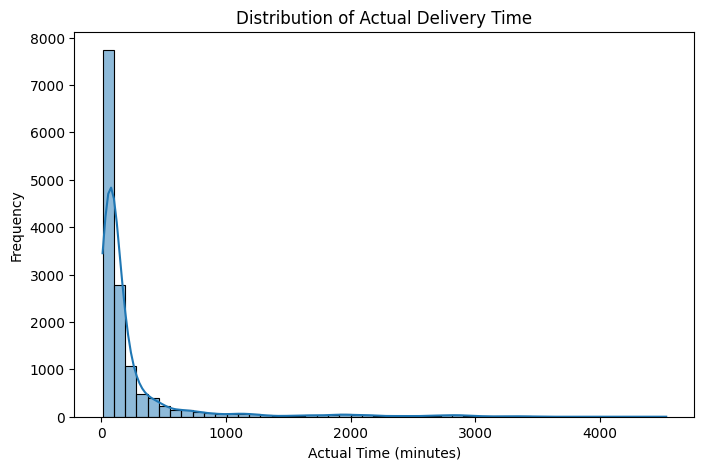

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(trip['actual_time'], bins=50, kde=True)

plt.title("Distribution of Actual Delivery Time")
plt.xlabel("Actual Time (minutes)")
plt.ylabel("Frequency")
plt.show()

- Observation - The delivery time distribution is highly right-skewed. Most deliveries are completed within 0–300 minutes, while a small number of trips take significantly longer, extending beyond 2000 minutes.

- Insight - This pattern indicates that the majority of deliveries operate within normal operational timelines, but a small fraction of trips experience extreme delays. These delays could be caused by long-distance routes, traffic congestion, or operational bottlenecks at logistics hubs.

#### **Distribution of Delhivery Distance**

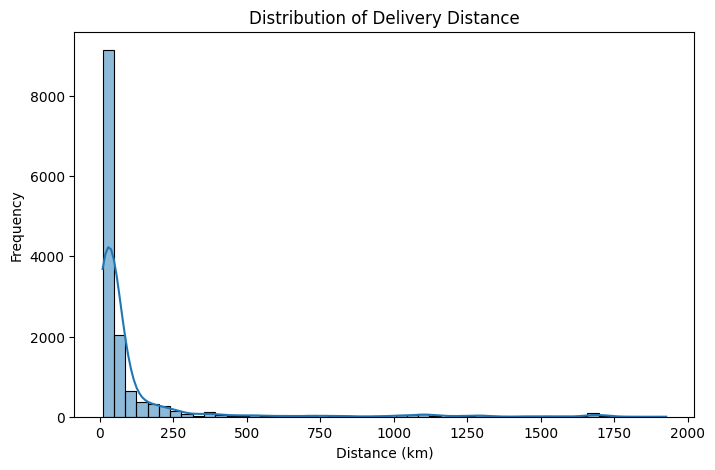

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(trip['actual_distance_to_destination'], bins=50, kde=True)

plt.title("Distribution of Delivery Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")
plt.show()

- Observation:- The distribution of delivery distance is also right-skewed. Most deliveries occur within short distances (below ~100 km), while a small number of long-haul deliveries extend up to 1900 km.

- Business Insight:- Delhivery’s operations appear to be dominated by short-distance regional deliveries, with fewer long-distance interstate shipments. Long-haul deliveries likely correspond to inter-city or cross-state transportation routes.

#### **Route Type Distribution**

[]

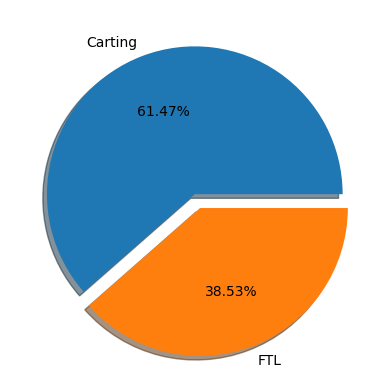

In [ ]:
plt.pie(data=trip,x=trip['route_type'].value_counts(),shadow=True,labels=['Carting','FTL'],explode=(0,0.1),autopct='%0.2f%%')
plt.plot()

- Observation :- Carting accounts for approximately 61.47% of trips, while FTL accounts for 38.53%.

- Business Insight :- Carting dominates the logistics operations, suggesting that multi-stop transportation using smaller vehicles is more common than full truckload shipments. This reflects the nature of e-commerce logistics where multiple packages are consolidated and distributed across several locations.

#### **Destination State with Delhivery Count**

In [ ]:
x = trip.groupby('destination_state')['trip_uuid'].count().sort_values(ascending=False).to_frame().reset_index()
x

,destination_state,trip_uuid
0,Maharashtra,2448
1,Karnataka,2243
2,Haryana,1616
3,Tamil Nadu,1034
4,Uttar Pradesh,731
5,Telangana,686
6,West Bengal,666
7,Delhi,657
8,Gujarat,622
9,Punjab,558


The highest number of deliveries are directed to:

- Maharashtra – 2448 trips

- Karnataka – 2243 trips

**Business Insight**

These states represent major logistics demand hubs. Maharashtra and Karnataka host large metropolitan areas such as Mumbai and Bengaluru, which are major e-commerce consumption centers.

#### **Source State with Delhivery Count**

In [ ]:
y=trip.groupby('source_state')['trip_uuid'].count().sort_values(ascending=False).to_frame().reset_index()
y

,source_state,trip_uuid
0,Maharashtra,2600
1,Karnataka,2106
2,Haryana,1793
3,Tamil Nadu,989
4,Delhi,725
5,Telangana,687
6,Uttar Pradesh,681
7,West Bengal,634
8,Gujarat,626
9,Rajasthan,473


**Observation**

The highest shipment origins are:

- Maharashtra – 2600 trips

- Karnataka – 2106 trips

- Haryana – 1793 trips

**Business Insight**

These states appear to be major logistics supply hubs, likely containing large warehouses or fulfillment centers from where shipments are dispatched to other regions.

#### **Analaysing through destination city, Which place have more delivery ?**

In [ ]:
z=trip.groupby('destination_city')['trip_uuid'].count().sort_values(ascending=False).head(11).to_frame().reset_index()
z

,destination_city,trip_uuid
0,Bengaluru,1088
1,Mumbai,913
2,Gurgaon,877
3,Delhi,554
4,Bangalore,538
5,Hyderabad,489
6,Bhiwandi,434
7,Chennai,406
8,Sonipat,322
9,Pune,313


**Observation**

The cities receiving the highest number of deliveries include:

- Bengaluru

- Mumbai

- Gurgaon

**Business Insight**

These cities are major urban demand centers, indicating that delivery volume is concentrated in highly populated metropolitan regions where e-commerce activity is high.

#### **Analaysing through source city, Which place have more delivery ?**

In [ ]:
w=trip.groupby('source_city')['trip_uuid'].count().sort_values(ascending=False).head(11).to_frame().reset_index()
w

,source_city,trip_uuid
0,Gurgaon,1128
1,Bengaluru,1052
2,Bhiwandi,697
3,Bangalore,648
4,Mumbai,601
5,Delhi,548
6,Hyderabad,507
7,Pune,467
8,Chennai,334
9,Mumbai Hub,300


**Observation**

The most frequent shipment origins include:

- Gurgaon

- Bengaluru

- Bhiwandi

**Business Insight**

Cities such as Gurgaon and Bhiwandi are well-known logistics hubs in India, suggesting that many shipments originate from centralized warehouses located near these cities.

### **Bivariate Analysis**

#### **Distance vs Delivery Time**

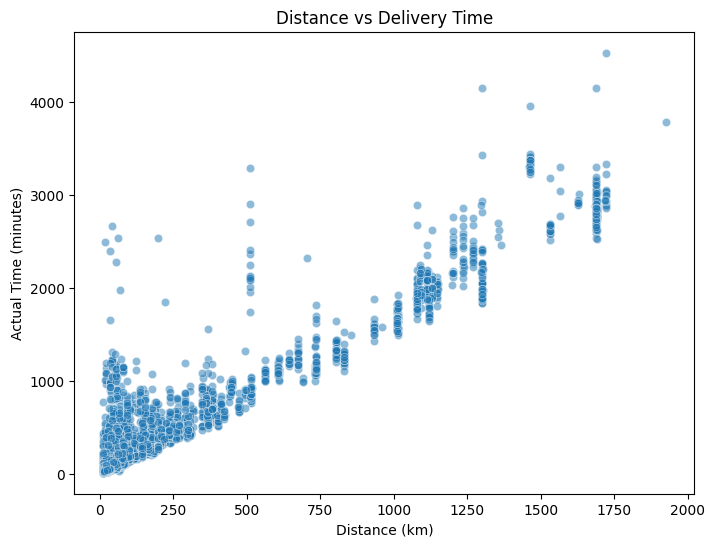

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='actual_distance_to_destination',y='actual_time',data=trip,alpha=0.5)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Actual Time (minutes)")
plt.show()

- Observation :- There is a strong positive relationship between delivery distance and delivery time. As the delivery distance increases, the actual delivery time also increases.

- Business Insight :- Distance is clearly one of the most important drivers of delivery time. This suggests that distance-based features will play a significant role in predicting delivery duration.

#### **OSRM Time vs Actual Time**

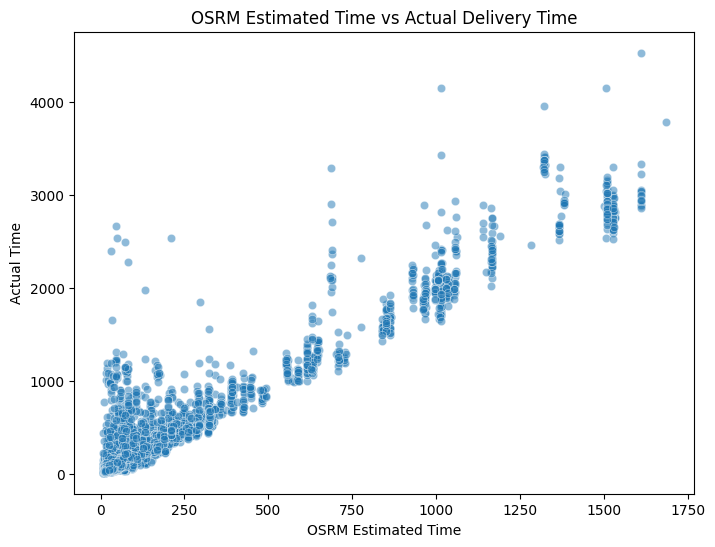

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='osrm_time',y='actual_time',data=trip,alpha=0.5)

plt.title("OSRM Estimated Time vs Actual Delivery Time")
plt.xlabel("OSRM Estimated Time")
plt.ylabel("Actual Time")
plt.show()

- Observation: The scatter plot shows that actual delivery time is usually higher than the OSRM estimated time.

- Business Insight: This indicates that OSRM route estimates consistently underestimate real delivery durations. The routing engine likely does not account for operational delays such as loading/unloading, traffic congestion, or intermediate hub processing.

#### **Delivery Time by Route Type**

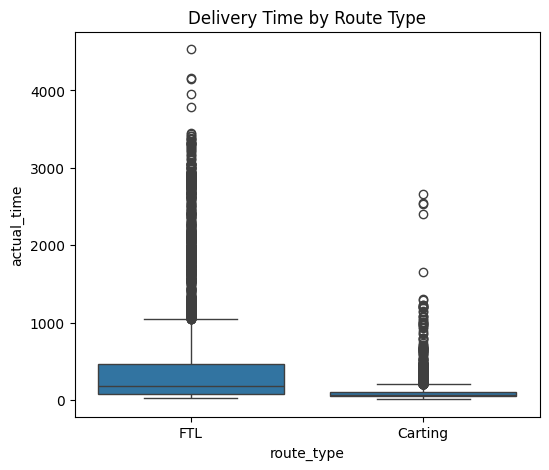

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='route_type', y='actual_time', data=trip)

plt.title("Delivery Time by Route Type")
plt.show()

- Observation: FTL deliveries exhibit higher variability and longer delivery times compared to Carting shipments.

- Business Insight: FTL shipments typically involve long-distance routes, which explains the wider spread of delivery times. Carting shipments are generally shorter, local deliveries, leading to more consistent delivery durations.

### **Multivariate Analysis**

#### **Correlation Heatmap**

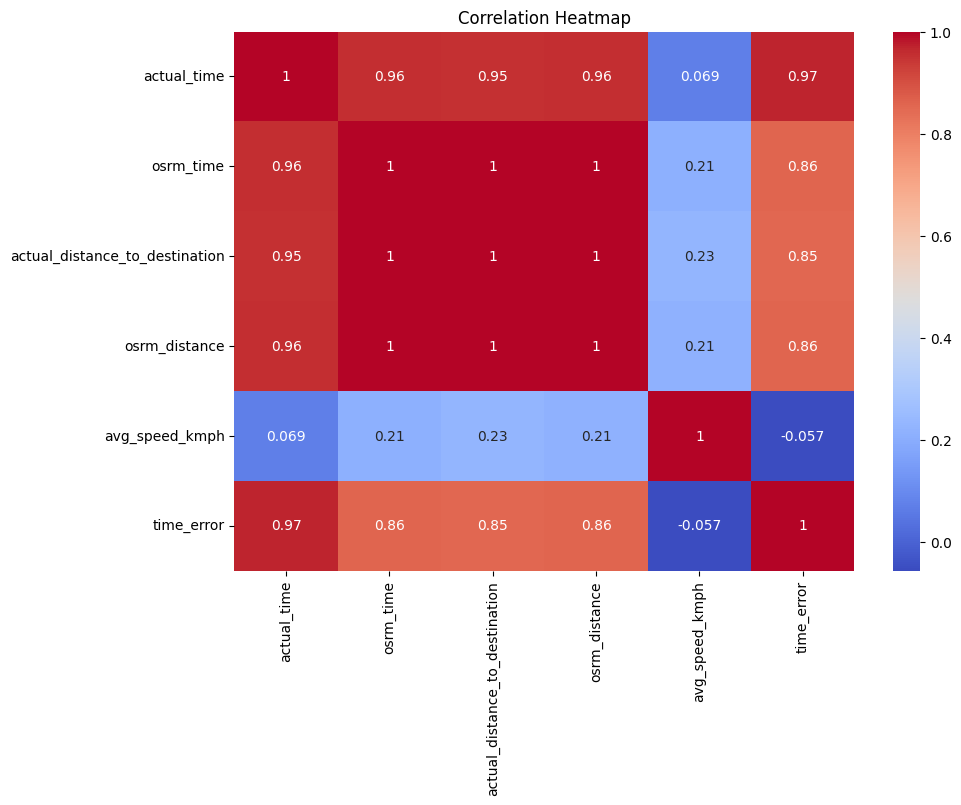

In [ ]:
plt.figure(figsize=(10,7))

corr = trip[['actual_time','osrm_time','actual_distance_to_destination',
             'osrm_distance','avg_speed_kmph','time_error']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

**Observation**

Strong positive correlations are observed between:

- Actual time and OSRM time (0.96)

- Actual time and actual distance (0.95)

- OSRM time and OSRM distance (~1.00)

**Business Insight**

These strong correlations confirm that delivery distance and estimated route metrics are key predictors of delivery time. Therefore, these variables will be highly useful for building predictive models.

#### **Average Speed vs Distance**

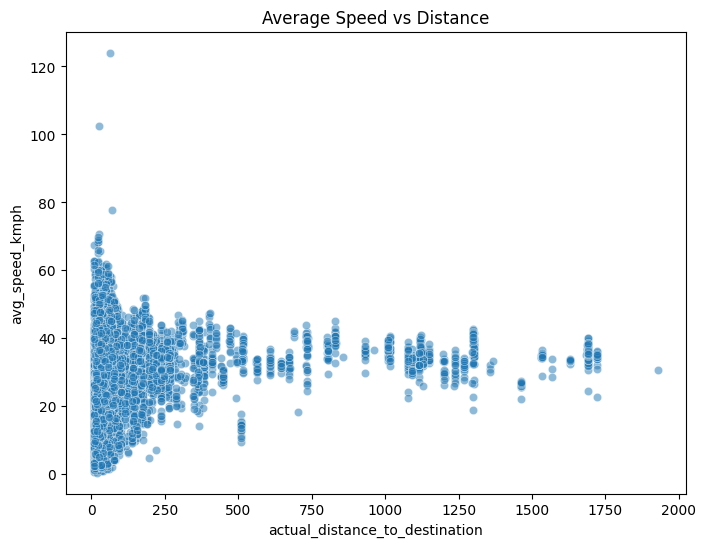

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='actual_distance_to_destination', y='avg_speed_kmph',data=trip,alpha=0.5)

plt.title("Average Speed vs Distance")
plt.show()

- Observation:Average delivery speed generally ranges between 20–40 km/h, regardless of distance.

- Business Insight: The relatively consistent speed range suggests that operational constraints such as traffic conditions and logistics processes maintain similar travel speeds across different routes.

#### **Overall EDA Insight**

The exploratory analysis reveals that delivery time is strongly influenced by travel distance and routing estimates. Most deliveries occur within short distances and moderate time ranges, while a small number of trips experience significant delays. Major logistics activity is concentrated around metropolitan cities and industrial hubs such as Mumbai, Bengaluru, and Gurgaon. These insights highlight key operational patterns that can help improve delivery forecasting and route optimization.

### **Outlier Detection & Treatment**

Outliers are extreme values that deviate significantly from the rest of the data. These values can distort statistical analysis and negatively impact machine learning models. Therefore, it is important to identify and handle outliers in numerical features.


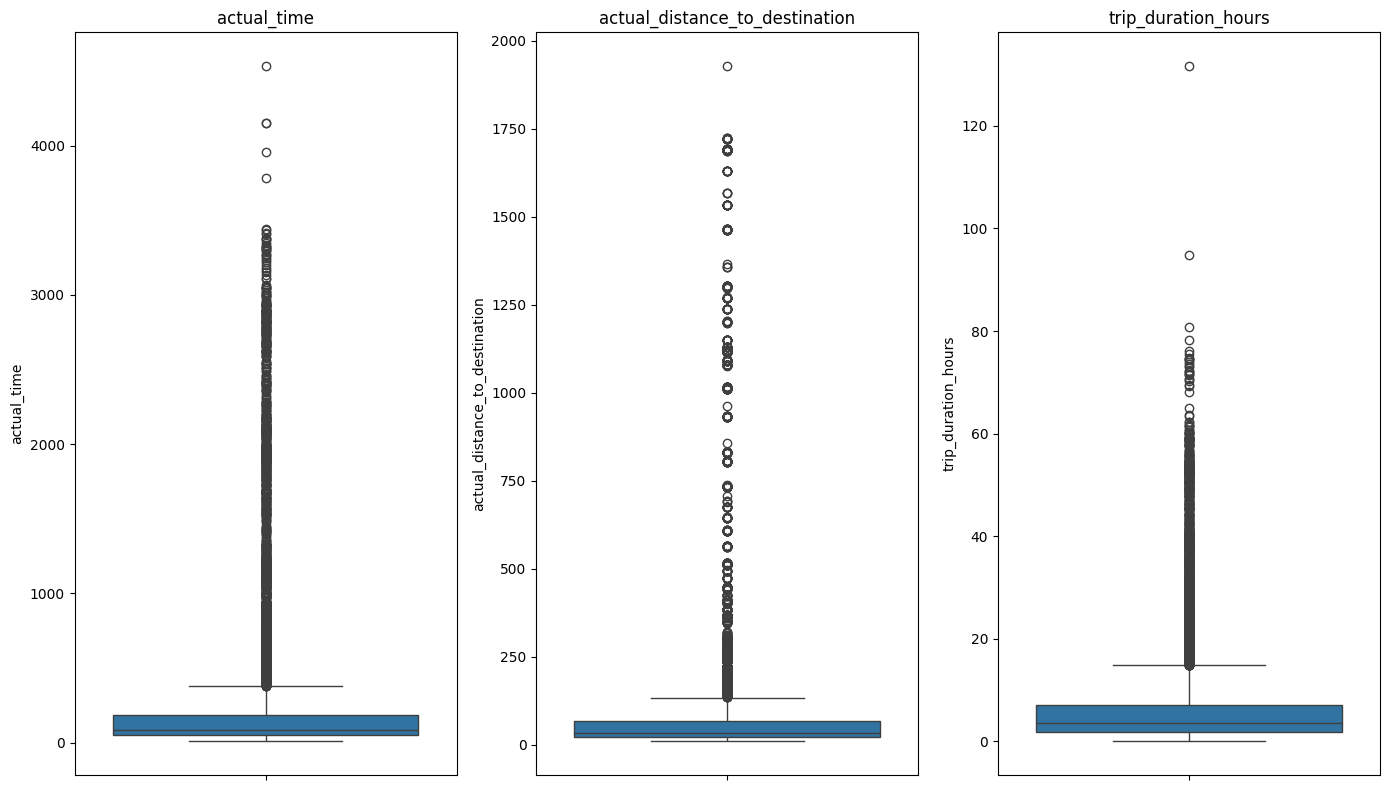

In [ ]:
# Visualizing Outliers using Boxplots
cols_for_outliers = [
    'actual_time',
    'actual_distance_to_destination',
    'trip_duration_hours'
]

plt.figure(figsize=(14,8))

for i,col in enumerate(cols_for_outliers):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=trip[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Observation**

The boxplots indicate the presence of several extreme values in delivery time, delivery distance, and trip duration. These values lie beyond the upper whiskers of the boxplots, suggesting that some trips take significantly longer or travel much farther than the majority of deliveries.

**Business Insight**

The presence of these extreme values may be attributed to:

- Long-distance interstate shipments

- Operational delays in logistics hubs

- Traffic congestion and route inefficiencies

- Possible data recording inconsistencies

Such extreme values can distort statistical analysis and machine learning models, making it necessary to treat them appropriately.

#### **Handling Outliers using IQR Method**

In [ ]:
cols_for_outliers = [
    'actual_time',
    'actual_distance_to_destination',
    'trip_duration_hours'
]

trip_clean = trip.copy()

for col in cols_for_outliers:

    Q1 = trip_clean[col].quantile(0.25)
    Q3 = trip_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    trip_clean = trip_clean[(trip_clean[col] >= lower) & (trip_clean[col] <= upper)]

print("Original:", trip.shape)
print("After cleaning:", trip_clean.shape)

Original: (13896, 27)
After cleaning: (10327, 27)


Since logistics operations may naturally contain long-distance deliveries, outlier treatment was applied cautiously only to critical operational variables to avoid removing valid long-haul shipments.

**Observation**

Using the IQR method, extreme values were filtered from the dataset. After removing outliers from key operational variables, the dataset size reduced from 13,896 rows to 10,327 rows.

**Insight**

The outlier removal process helps ensure that the dataset better represents typical delivery operations, while eliminating unusually large values that could bias analysis and predictive modeling.

### **One - Hot Encoding**

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , MinMaxScaler , OneHotEncoder

cat_cols = ['data','route_type']

In [ ]:
ohe = OneHotEncoder(sparse_output=False)
encoded_cat_cols = ohe.fit_transform(trip_clean[cat_cols])
encoded_df = pd.DataFrame(encoded_cat_cols,columns=ohe.get_feature_names_out(cat_cols),index=trip_clean.index)
encoded_df

,data_test,data_training,route_type_Carting,route_type_FTL
1,0.0,1.0,1.0,0.0
3,0.0,1.0,1.0,0.0
4,0.0,1.0,0.0,1.0
5,0.0,1.0,1.0,0.0
6,0.0,1.0,1.0,0.0
...,...,...,...,...
14782,1.0,0.0,1.0,0.0
14783,1.0,0.0,1.0,0.0
14784,1.0,0.0,1.0,0.0
14785,1.0,0.0,1.0,0.0


In [ ]:
trip_encoded = pd.concat([trip_clean, encoded_df], axis=1)

print("Shape after encoding:", trip_encoded.shape)
trip_encoded.head()

Shape after encoding: (10327, 31)


,trip_uuid,data,trip_creation_time,route_schedule_uuid,route_type,source_center,destination_center,od_start_time,od_end_time,actual_distance_to_destination,...,source_city,destination_city,source_state,destination_state,avg_speed_kmph,time_error,data_test,data_training,route_type_Carting,route_type_FTL
1,trip-153671042288605164,training,2018-09-12 00:00:23,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,IND561203AAB,IND561203AAB,2018-09-12 02:03:10,2018-09-12 02:03:10,48.542890,...,Doddablpur,Doddablpur,Karnataka,Karnataka,30.339306,54,0.0,1.0,1.0,0.0
3,trip-153671046011330457,training,2018-09-12 00:01:00,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f...,Carting,IND400072AAB,IND401104AAA,2018-09-12 00:01:00,2018-09-12 01:41:30,17.175274,...,Mumbai Hub,Mumbai,Maharashtra,Maharashtra,17.466381,44,0.0,1.0,1.0,0.0
4,trip-153671052974046625,training,2018-09-12 00:02:10,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df06134...,FTL,IND583101AAA,IND583119AAA,2018-09-12 00:02:10,2018-09-12 03:54:43,26.600536,...,Bellary,Sandur,Karnataka,Karnataka,25.333844,36,0.0,1.0,0.0,1.0
5,trip-153671055416136166,training,2018-09-12 00:02:34,thanos::sroute:9bf03170-d0a2-4a3f-aa4d-9aaab3d...,Carting,IND600056AAA,IND600056AAA,2018-09-12 02:12:11,2018-09-12 02:12:11,9.271519,...,Chennai,Chennai,Tamil Nadu,Tamil Nadu,26.490056,10,0.0,1.0,1.0,0.0
6,trip-153671066201138152,training,2018-09-12 00:04:22,thanos::sroute:a97698cc-846e-41a7-916b-88b1741...,Carting,IND600044AAD,IND600048AAA,2018-09-12 00:04:22,2018-09-12 01:42:22,9.100510,...,Chennai,Chennai,Tamil Nadu,Tamil Nadu,22.751275,11,0.0,1.0,1.0,0.0


In [ ]:
trip_temp = trip_encoded.drop(columns=['data', 'route_type', 'data_test', 'route_type_Carting'])
trip_temp.head()

,trip_uuid,trip_creation_time,route_schedule_uuid,source_center,destination_center,od_start_time,od_end_time,actual_distance_to_destination,actual_time,osrm_time,...,trip_weekday,trip_hour,source_city,destination_city,source_state,destination_state,avg_speed_kmph,time_error,data_training,route_type_FTL
1,trip-153671042288605164,2018-09-12 00:00:23,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,IND561203AAB,IND561203AAB,2018-09-12 02:03:10,2018-09-12 02:03:10,48.542890,96,42,...,2,0,Doddablpur,Doddablpur,Karnataka,Karnataka,30.339306,54,1.0,0.0
3,trip-153671046011330457,2018-09-12 00:01:00,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f...,IND400072AAB,IND401104AAA,2018-09-12 00:01:00,2018-09-12 01:41:30,17.175274,59,15,...,2,0,Mumbai Hub,Mumbai,Maharashtra,Maharashtra,17.466381,44,1.0,0.0
4,trip-153671052974046625,2018-09-12 00:02:10,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df06134...,IND583101AAA,IND583119AAA,2018-09-12 00:02:10,2018-09-12 03:54:43,26.600536,63,27,...,2,0,Bellary,Sandur,Karnataka,Karnataka,25.333844,36,1.0,1.0
5,trip-153671055416136166,2018-09-12 00:02:34,thanos::sroute:9bf03170-d0a2-4a3f-aa4d-9aaab3d...,IND600056AAA,IND600056AAA,2018-09-12 02:12:11,2018-09-12 02:12:11,9.271519,21,11,...,2,0,Chennai,Chennai,Tamil Nadu,Tamil Nadu,26.490056,10,1.0,0.0
6,trip-153671066201138152,2018-09-12 00:04:22,thanos::sroute:a97698cc-846e-41a7-916b-88b1741...,IND600044AAD,IND600048AAA,2018-09-12 00:04:22,2018-09-12 01:42:22,9.100510,24,13,...,2,0,Chennai,Chennai,Tamil Nadu,Tamil Nadu,22.751275,11,1.0,0.0


Categorical features were transformed using One-Hot Encoding to convert them into numerical form suitable for machine learning algorithms. Redundant dummy variables were removed to prevent multicollinearity.

### **Feature Scaling**

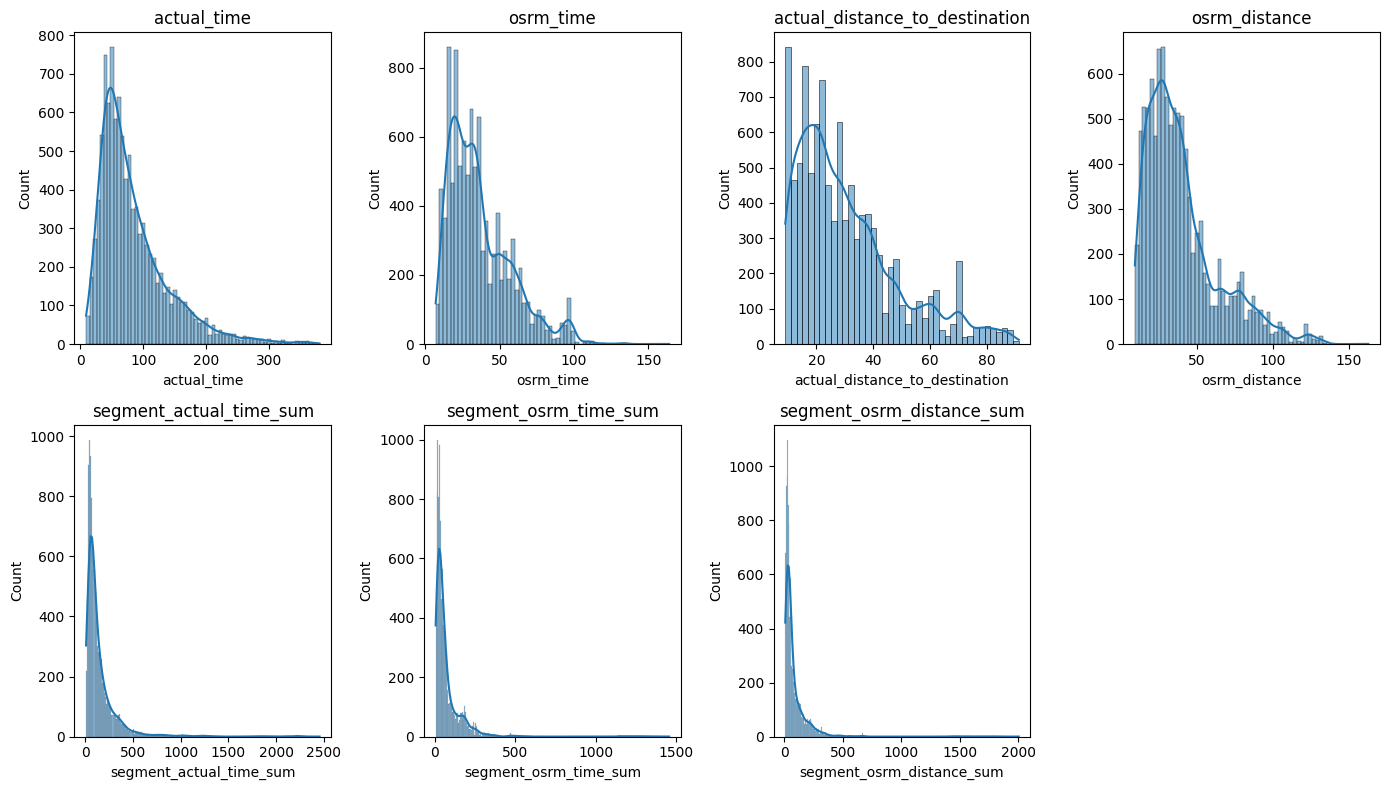

In [ ]:
num_cols = [
'actual_time',
'osrm_time',
'actual_distance_to_destination',
'osrm_distance',
'segment_actual_time_sum',
'segment_osrm_time_sum',
'segment_osrm_distance_sum'
]

plt.figure(figsize=(14,8))

for i,col in enumerate(num_cols):
    plt.subplot(2,4,i+1)
    sns.histplot(trip_clean[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

The histograms show that most numerical variables are right-skewed, with a large concentration of observations at lower values and a long tail extending toward higher values. This skewness indicates that the dataset does not follow a Gaussian distribution, which influences the choice of feature scaling technique.

#### **Minmax scaler - Most appropriate since the data is not gaussian**

MinMaxScaler transforms features to a range between 0 and 1, which helps machine learning models perform better when features have different scales.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

trip_temp[num_cols] = scaler.fit_transform(trip_temp[num_cols])

trip_temp.head()

,trip_uuid,trip_creation_time,route_schedule_uuid,source_center,destination_center,od_start_time,od_end_time,actual_distance_to_destination,actual_time,osrm_time,...,trip_weekday,trip_hour,source_city,destination_city,source_state,destination_state,avg_speed_kmph,time_error,data_training,route_type_FTL
1,trip-153671042288605164,2018-09-12 00:00:23,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,IND561203AAB,IND561203AAB,2018-09-12 02:03:10,2018-09-12 02:03:10,0.480588,0.233871,0.222930,...,2,0,Doddablpur,Doddablpur,Karnataka,Karnataka,30.339306,54,1.0,0.0
3,trip-153671046011330457,2018-09-12 00:01:00,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f...,IND400072AAB,IND401104AAA,2018-09-12 00:01:00,2018-09-12 01:41:30,0.099335,0.134409,0.050955,...,2,0,Mumbai Hub,Mumbai,Maharashtra,Maharashtra,17.466381,44,1.0,0.0
4,trip-153671052974046625,2018-09-12 00:02:10,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df06134...,IND583101AAA,IND583119AAA,2018-09-12 00:02:10,2018-09-12 03:54:43,0.213893,0.145161,0.127389,...,2,0,Bellary,Sandur,Karnataka,Karnataka,25.333844,36,1.0,1.0
5,trip-153671055416136166,2018-09-12 00:02:34,thanos::sroute:9bf03170-d0a2-4a3f-aa4d-9aaab3d...,IND600056AAA,IND600056AAA,2018-09-12 02:12:11,2018-09-12 02:12:11,0.003270,0.032258,0.025478,...,2,0,Chennai,Chennai,Tamil Nadu,Tamil Nadu,26.490056,10,1.0,0.0
6,trip-153671066201138152,2018-09-12 00:04:22,thanos::sroute:a97698cc-846e-41a7-916b-88b1741...,IND600044AAD,IND600048AAA,2018-09-12 00:04:22,2018-09-12 01:42:22,0.001192,0.040323,0.038217,...,2,0,Chennai,Chennai,Tamil Nadu,Tamil Nadu,22.751275,11,1.0,0.0


- Observation: After applying MinMax scaling, all numerical variables are transformed into a range between 0 and 1, ensuring consistent feature scales.

- Insight: Since the dataset is not normally distributed, MinMaxScaler is more appropriate than StandardScaler, as it scales the data without assuming normality. This prevents features with larger numerical ranges from dominating the model.

## **Hypothesis Testing**

**1. Are aggregated actual_time and aggregated osrm_time similar?**
Setting Significance level = 0.05

**STEP-1 :** Set up Null Hypothesis & Alternate Hypothesis

- Null Hypothesis ( $H$0 ) - There is no significant difference in the mean values between column1 and column2

- Alternate Hypothesis( $H$A ) - There is a significant difference in the mean values between column1 and column2

**Step-2 :** Visual Analysis

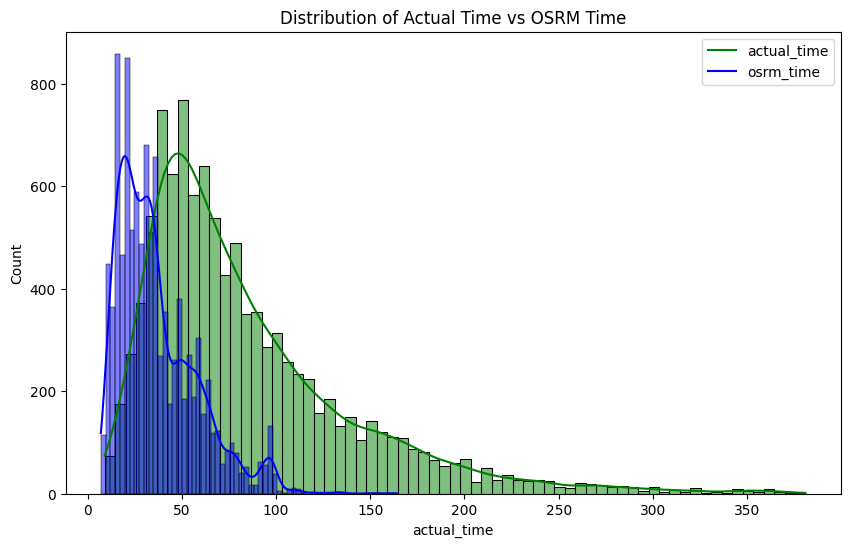

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(trip_clean['actual_time'], color='green', kde=True)
sns.histplot(trip_clean['osrm_time'], color='blue', kde=True)

plt.legend(['actual_time','osrm_time'])
plt.title("Distribution of Actual Time vs OSRM Time")

plt.show()

The distribution of actual delivery time is shifted toward higher values compared to OSRM estimated time, indicating that the routing engine tends to underestimate delivery durations.

Since your dataset contains over 10,000 observations, the Central Limit Theorem applies.

This means that even if the difference is not perfectly normal, the paired t-test remains reliable for large samples.

**Step-3 :** Perform test

In [ ]:
from scipy.stats import ttest_rel

t_stat , p_value = ttest_rel(trip_clean['actual_time'],trip_clean['osrm_time'])

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 107.74248559261038
P-value: 0.0


In [ ]:
def accept_reject(p_value, alpha=0.05):
    if p_value > alpha:
        print(f'Fail to reject null hypothesis (p-value = {p_value:.4f} > {alpha})')
        print('Result is NOT statistically significant')
    else:
        print(f'Reject null hypothesis (p-value = {p_value:.4f} <= {alpha})')
        print('Result IS statistically significant')

In [ ]:
accept_reject(p_value)

Reject null hypothesis (p-value = 0.0000 <= 0.05)
Result IS statistically significant


This indicates that actual delivery times are significantly different from OSRM estimated times.

In most cases, actual delivery time is higher, suggesting that the routing engine does not fully account for real-world factors such as:

- Traffic congestion

- Loading/unloading delays

- Warehouse processing time

- Route disruptions

**2. Are aggregated actual_time and aggregated segment_actual_time_sum similar?**

**Step 1 —** Define Hypotheses

- Null Hypothesis (H₀): There is no significant difference between the mean of actual_time and segment_actual_time_sum.

- Alternative Hypothesis (H₁): There is a significant difference between the mean of actual_time and segment_actual_time_sum.

**Step 2 -** Visual Analysis

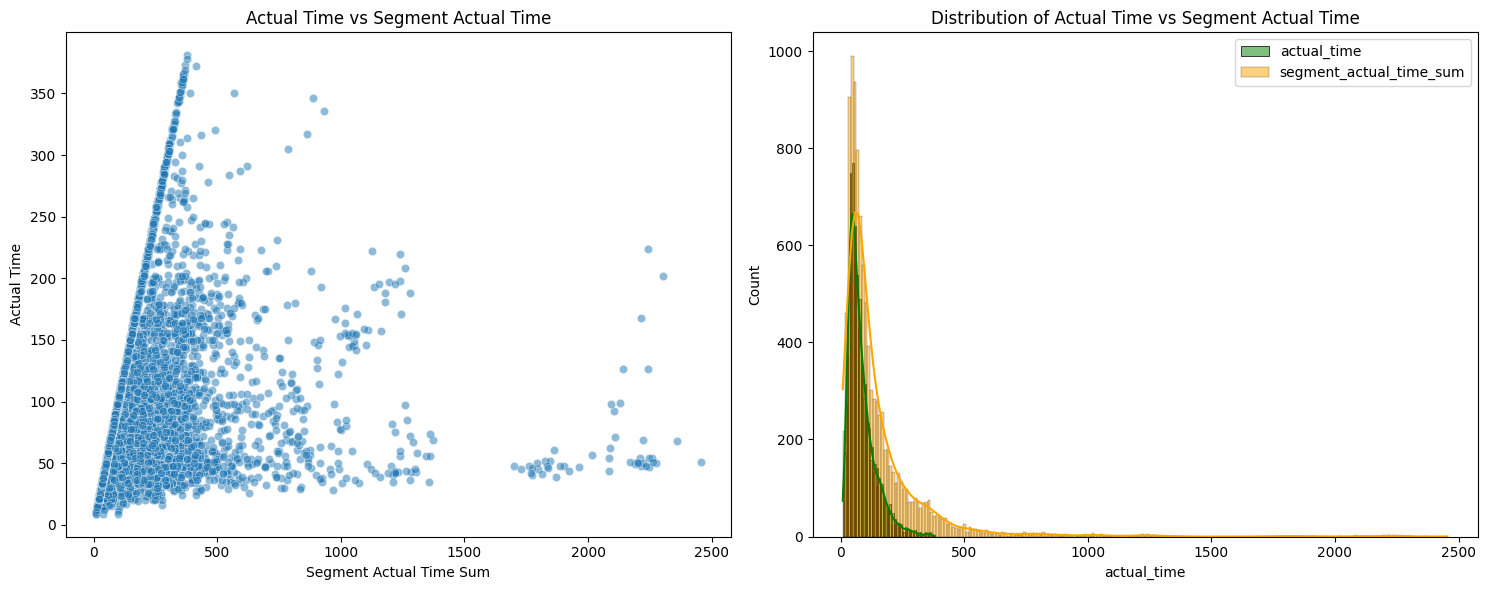

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# First subplot - Scatter plot
sns.scatterplot(x='segment_actual_time_sum',y='actual_time',data=trip_clean,alpha=0.5,ax=ax1 )
ax1.set_title("Actual Time vs Segment Actual Time")
ax1.set_xlabel("Segment Actual Time Sum")
ax1.set_ylabel("Actual Time")

# Second subplot - Histogram with KDE
sns.histplot(trip_clean['actual_time'], color='green', kde=True, ax=ax2, label='actual_time')
sns.histplot(trip_clean['segment_actual_time_sum'], color='orange', kde=True, ax=ax2, label='segment_actual_time_sum')
ax2.set_title("Distribution of Actual Time vs Segment Actual Time")
ax2.legend()

plt.tight_layout()
plt.show()

The distribution of segment_actual_time_sum appears shifted toward higher values compared to actual_time, indicating that the sum of segment travel times is often larger than the total recorded trip time.

A positive relationship exists between segment-level actual time and total trip delivery time.

**Step 3 -** Check Assumption (Normality of Differences)


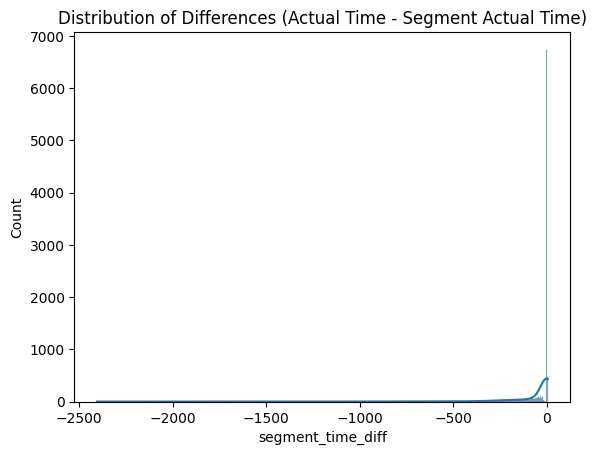

In [ ]:
trip_clean['segment_time_diff'] = (trip_clean['actual_time'] - trip_clean['segment_actual_time_sum'])

sns.histplot(trip_clean['segment_time_diff'], kde=True)

plt.title("Distribution of Differences (Actual Time - Segment Actual Time)")
plt.show()

Although the distribution may not be perfectly normal, the dataset contains a large number of observations, so the Central Limit Theorem allows the paired t-test to remain valid.

**Step 4 —** Perform Paired T-Test

In [ ]:
t_stat , p_value = ttest_rel(trip_clean['actual_time'],trip_clean['segment_actual_time_sum'])

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -35.459787050319996
P-value: 5.2902043148433084e-260


In [ ]:
accept_reject(p_value)

Reject null hypothesis (p-value = 0.0000 <= 0.05)
Result IS statistically significant


The p-value obtained from the paired t-test is less than 0.05, indicating a statistically significant difference between actual_time and segment_actual_time_sum.

**Insight**

This suggests that the sum of segment travel times differs from the recorded total trip time. The difference may arise because segment-level times include additional operational activities such as scanning, loading, and hub processing, which may not directly contribute to the overall trip duration.

**3. Are aggregated osrm_distance and segment_osrm_distance_sum similar?**

**Step 1 —** Define Hypotheses

- Null Hypothesis (H₀): There is no significant difference between the mean of osrm_distance and segment_osrm_distance_sum.

- Alternative Hypothesis (H₁): There is a significant difference between the mean of osrm_distance and segment_osrm_distance_sum.

**Step 2 -** Visual Analysis

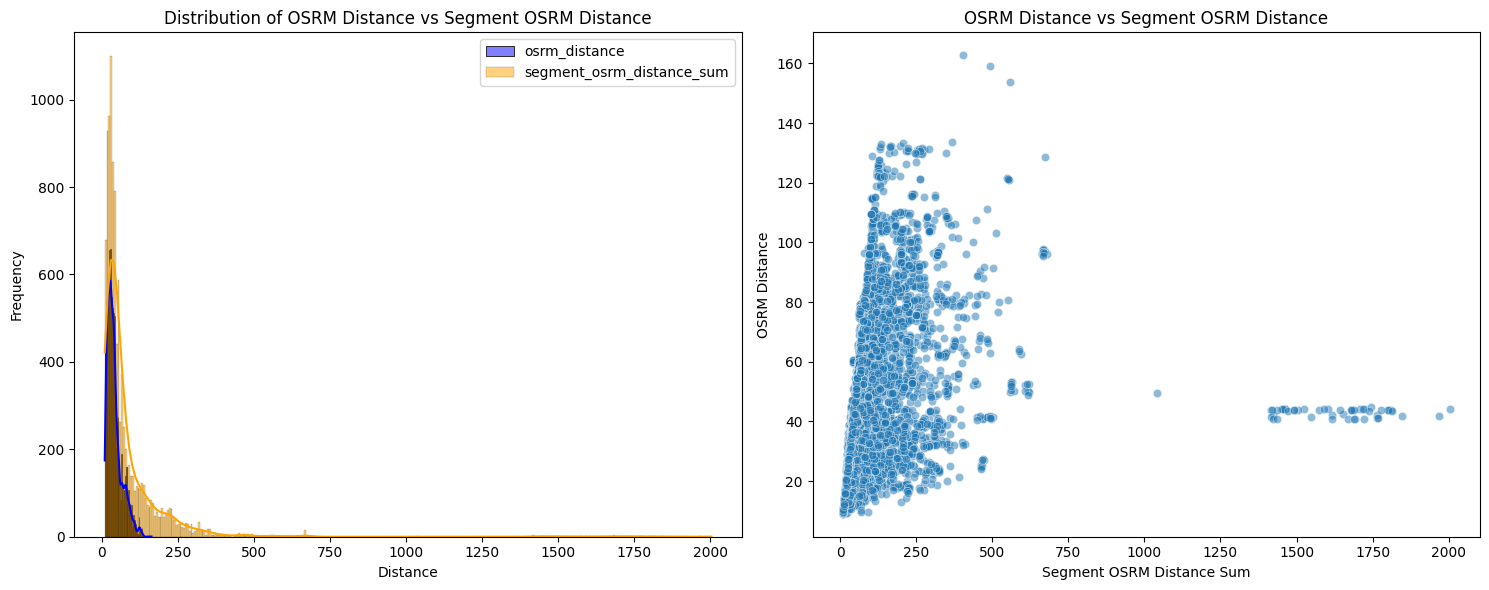

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# First subplot - Histogram with KDE
sns.histplot(trip_clean['osrm_distance'], color='blue', kde=True, ax=ax1, label='osrm_distance')
sns.histplot(trip_clean['segment_osrm_distance_sum'], color='orange', kde=True, ax=ax1, label='segment_osrm_distance_sum')
ax1.set_title("Distribution of OSRM Distance vs Segment OSRM Distance")
ax1.legend()
ax1.set_xlabel("Distance")
ax1.set_ylabel("Frequency")

# Second subplot - Scatter plot
sns.scatterplot(
    x='segment_osrm_distance_sum',
    y='osrm_distance',
    data=trip_clean,
    alpha=0.5,
    ax=ax2
)
ax2.set_title("OSRM Distance vs Segment OSRM Distance")
ax2.set_xlabel("Segment OSRM Distance Sum")
ax2.set_ylabel("OSRM Distance")

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

Both variables show similar distribution patterns, suggesting that the total OSRM route distance is closely related to the sum of segment-level OSRM distances.

The scatter plot shows a strong positive linear relationship between segment_osrm_distance_sum and osrm_distance.

**Step 4 —** Perform Paired T-Test

In [ ]:
t_stat , p_value = ttest_rel(trip_clean['osrm_distance'],trip_clean['segment_osrm_distance_sum'])

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -34.410152975261305
P-value: 9.477019935173543e-246


In [ ]:
accept_reject(p_value)

Reject null hypothesis (p-value = 0.0000 <= 0.05)
Result IS statistically significant


The p-value obtained from the paired t-test is less than 0.05, indicating a statistically significant difference between osrm_distance and segment_osrm_distance_sum.

The slight difference between aggregated OSRM distance and the sum of segment-level OSRM distances may arise due to route adjustments, intermediate stops, or rounding differences in distance calculations. However, the strong relationship confirms that segment-level routing estimates are largely consistent with overall route distance predictions.

**4. Are aggregated osrm_time and segment_osrm_time_sum similar?**

**Step 1 —** Define Hypotheses

- Null Hypothesis (H₀): There is no significant difference between the mean of osrm_time and segment_osrm_time_sum.

- Alternative Hypothesis (H₁): There is a significant difference between the mean of osrm_time and segment_osrm_time_sum.

**Step 2 -** Visual Analysis

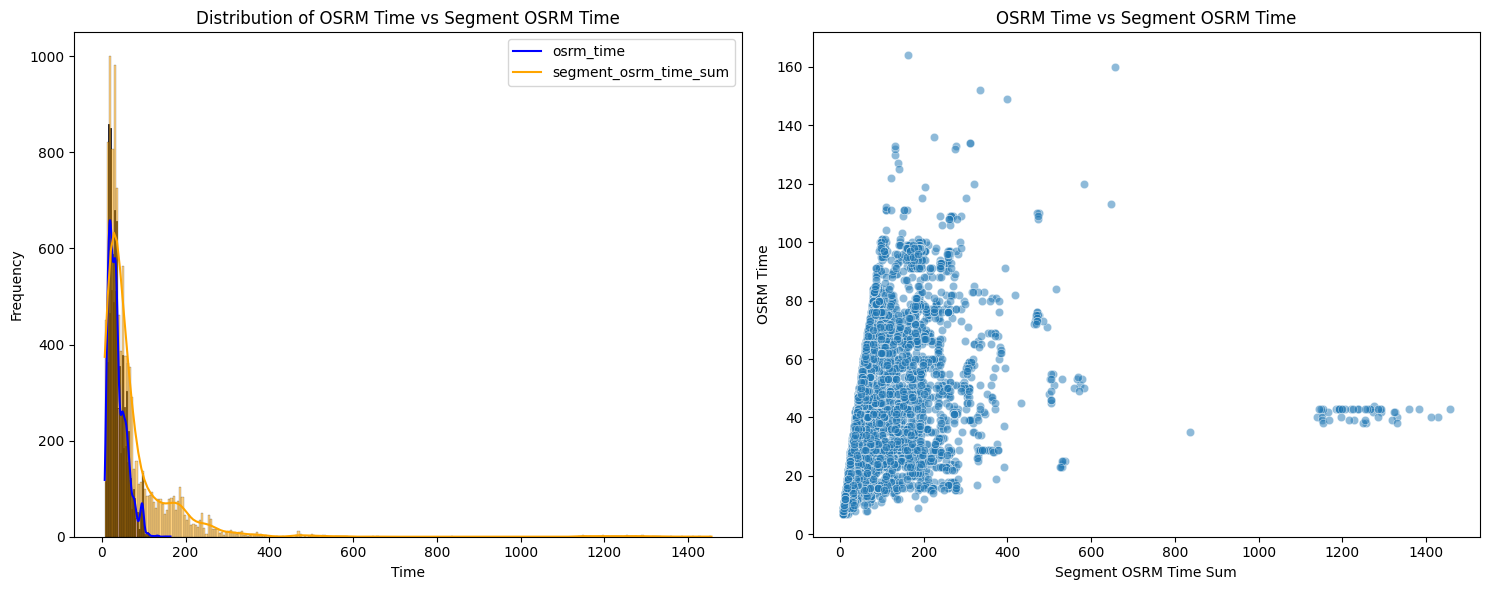

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# First subplot - Histogram with KDE
sns.histplot(trip_clean['osrm_time'], color='blue', kde=True, ax=ax1, label='osrm_time')
sns.histplot(trip_clean['segment_osrm_time_sum'], color='orange', kde=True, ax=ax1, label='segment_osrm_time_sum')
ax1.set_title("Distribution of OSRM Time vs Segment OSRM Time")
ax1.legend(['osrm_time', 'segment_osrm_time_sum'])
ax1.set_xlabel("Time")
ax1.set_ylabel("Frequency")

# Second subplot - Scatter plot
sns.scatterplot(x='segment_osrm_time_sum',y='osrm_time',data=trip_clean,alpha=0.5,ax=ax2)
ax2.set_title("OSRM Time vs Segment OSRM Time")
ax2.set_xlabel("Segment OSRM Time Sum")
ax2.set_ylabel("OSRM Time")

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

Both variables display similar distribution shapes, indicating that the total OSRM travel time is closely related to the sum of segment-level OSRM travel times.

The scatter plot shows a strong positive linear relationship between segment_osrm_time_sum and osrm_time.

**Step 3 —** Perform Paired T-Test

In [ ]:
t_stat , p_value = ttest_rel(trip_clean['osrm_time'],trip_clean['segment_osrm_time_sum'])

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -37.79925760053928
P-value: 5.828985359199367e-293


In [ ]:
accept_reject(p_value)

Reject null hypothesis (p-value = 0.0000 <= 0.05)
Result IS statistically significant


The p-value obtained from the paired t-test is less than 0.05, indicating a statistically significant difference between osrm_time and segment_osrm_time_sum.

**Insight:**

The difference between aggregated OSRM travel time and the sum of segment-level OSRM times may arise due to routing adjustments, intermediate hub delays, or estimation approximations in the routing engine. Nevertheless, the strong relationship confirms that segment-level routing predictions are generally consistent with the overall route travel time estimate.

## **Business Insight**

- The dataset covers deliveries between 12 September 2018 and 8 October 2018, representing approximately 26 days of logistics operations.

- Most numerical variables such as actual_time, osrm_time, and distance features are right-skewed, indicating that while most deliveries occur within normal operational ranges, a smaller number of trips take significantly longer due to long-distance routes or operational delays.

- Delivery time and distance show strong positive correlations, indicating that distance is one of the primary drivers of delivery duration.

- Hypothesis testing results indicate that actual delivery time differs significantly from OSRM estimated time. This suggests that the routing engine systematically underestimates delivery time, likely because it does not fully account for:

  - traffic congestion

  - loading and unloading delays

  - warehouse processing time

  - route diversions

- The top source and destination states are: Maharashtra, Karnataka, and Haryana. This indicates that a large portion of logistics activity is concentrated in major economic hubs and industrial corridors.

- The cities with the highest shipment activity include: Bengaluru, Mumbai, and Gurgaon. These cities likely act as major logistics hubs in the Delhivery network.

- Hypothesis testing between aggregated values and segment-level values shows that:

  - segment times and distances are strongly correlated with trip-level metrics

  - however, small statistical differences exist due to operational activities between segments

This confirms that segment aggregation logic is largely correct.

- Carting shipments account for a large share of deliveries, indicating that many shipments involve multi-stop local delivery operations rather than full truckload shipments.

## **Business Recommendation**

- Since OSRM estimated time significantly differs from actual delivery time, Delhivery should enhance routing models by incorporating: traffic patterns, warehouse handling time, and regional congestion trends. This would improve delivery time prediction accuracy.

- States such as Maharashtra, Karnataka, Haryana, Tamil Nadu, Telangana, and Gujarat show high shipment activity. Optimizing logistics infrastructure and route planning in these corridors could significantly improve operational efficiency.

- Differences between segment-level travel time and total trip time suggest possible delays at intermediate hubs. Improving hub processing time could reduce overall delivery duration.

- Differences between segment-level travel time and total trip time suggest possible delays at intermediate hubs. Improving hub processing time could reduce overall delivery duration.

- The routing engine should continuously update routes using real-time data, including traffic patterns and historical delivery performance.

- Since delivery time strongly depends on distance, incorporating distance-based predictive models could improve delivery time forecasting accuracy.

**Conclusion**

The analysis highlights that delivery time is strongly influenced by travel distance and operational factors such as routing efficiency and hub processing time. While OSRM provides useful route estimates, the observed differences between estimated and actual delivery times suggest opportunities for improving prediction accuracy. By optimizing high-traffic corridors, enhancing routing algorithms, and improving hub-level operations, Delhivery can significantly improve delivery efficiency and customer satisfaction.